# Adding rotation — off-grid + relative orientation

This notebook adds a **uniformly random per-patch rotation** to the off-grid
sampling from [`01_offgrid_sampling.ipynb`](01_offgrid_sampling.ipynb), and lets
us **visually assess the resampling artefacts** — the *interpolation confound*
that is Validity threat #1 for RoPART (a model could read rotation-correlated blur
instead of learning orientation).

Patches are rotated **about their centre** (the rotation-invariant anchor),
with a single `grid_sample` resampling. We then build the RoPART relative-
orientation target `Δφ` as `(cos Δφ, sin Δφ)` and check its invariants — the
rotational analogue of the translation section in notebook 01.

Everything stays additive: the baseline (no-rotation) path is untouched.

In [1]:
%load_ext autoreload
%autoreload 2

import math
import torch
import matplotlib.pyplot as plt

from helpers import (
    load_image,
    sample_offgrid_patches,
    sample_rotation_angles,
    crop_patches,
    crop_patches_rotated,
    retile_patches,
    rotation_window_size,
    rotation_margin,
    relative_orientation,
    check_orientation_invariants,
    draw_rotated_boxes,
    show_patch_grid,
    show_rotation_sweep,
    show_orientation_pair,
)

## 1. Sample off-grid boxes **and** rotations

Two new pieces vs notebook 01:

- `sample_rotation_angles(N)` draws one orientation per patch, uniform on
  `[0, 2π)` — a uniformly random rotation in SO(2).
- `sample_offgrid_patches(..., margin=rotation_margin(PATCH_SIZE))` keeps every
  patch centre far enough from the edges that the **diagonal-sized** source window
  needed to fill a rotated patch (`ceil(patch_size·√2)`) stays inside the image.

In [2]:
IMG_SIZE = 512
PATCH_SIZE = 64
NUM_PATCHES = 64

image = load_image("example.jpeg", img_size=IMG_SIZE)

MARGIN = rotation_margin(PATCH_SIZE)
print(f"rotation window = {rotation_window_size(PATCH_SIZE)}px (= ceil({PATCH_SIZE}·√2)),  margin = {MARGIN}px")

g = torch.Generator().manual_seed(0)
boxes = sample_offgrid_patches(IMG_SIZE, PATCH_SIZE, NUM_PATCHES, margin=MARGIN, generator=g)
angles = sample_rotation_angles(NUM_PATCHES, generator=g)   # radians, U[0, 2π)

print("boxes :", tuple(boxes.shape), "| angles:", tuple(angles.shape))
print("angles (deg), first 8:", [round(math.degrees(a)) for a in angles[:8].tolist()])

rotation window = 91px (= ceil(64·√2)),  margin = 14px
boxes : (4, 64) | angles: (64,)
angles (deg), first 8: [117, 32, 142, 218, 63, 171, 309, 161]


## 2. Where they are, and how they're turned

`draw_rotated_boxes` overlays each patch's **rotated footprint** (the exact region
read from the source) plus an **orientation tick** along the patch's local +x
axis, so the orientation is unambiguous even for near-symmetric content.

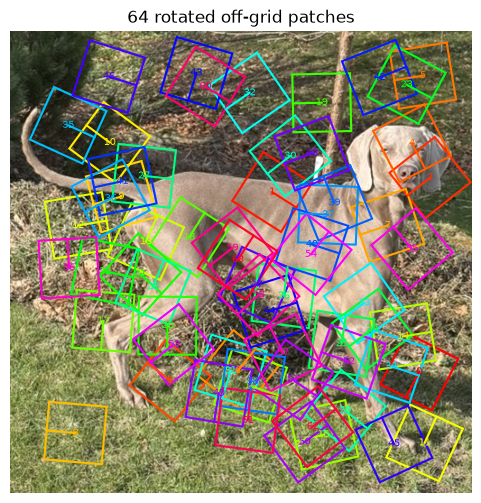

In [3]:
draw_rotated_boxes(image, boxes, angles, title=f"{NUM_PATCHES} rotated off-grid patches")
plt.show()

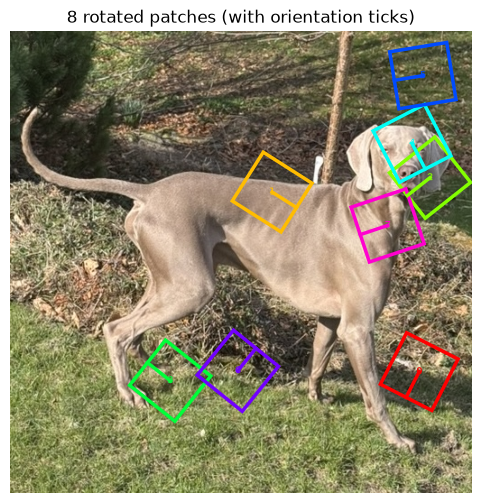

In [4]:
# fewer, thicker for clarity
draw_rotated_boxes(image, boxes[:, :8], angles[:8], title="8 rotated patches (with orientation ticks)", linewidth=2.5)
plt.show()

## 3. The rotated patches, and the ViT input

`crop_patches_rotated` resamples each patch once. With `fill_corners=True`
(default) it reads from the full image, so the rotated patches have **no empty
corners**. We then row-major pack them exactly as before — the scrambled
pseudo-image the ViT ingests.

patches: (64, 3, 64, 64) | black-pixel fraction: 0.0


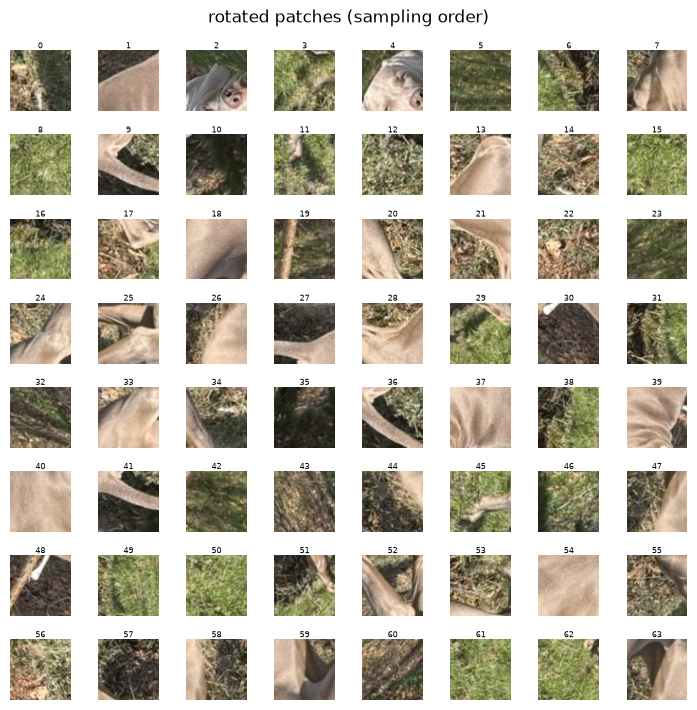

In [5]:
patches = crop_patches_rotated(image, boxes, angles)   # (N, C, P, P), fill_corners=True
print("patches:", tuple(patches.shape), "| black-pixel fraction:", round((patches == 0).float().mean().item(), 4))

show_patch_grid(patches, title="rotated patches (sampling order)")
plt.show()

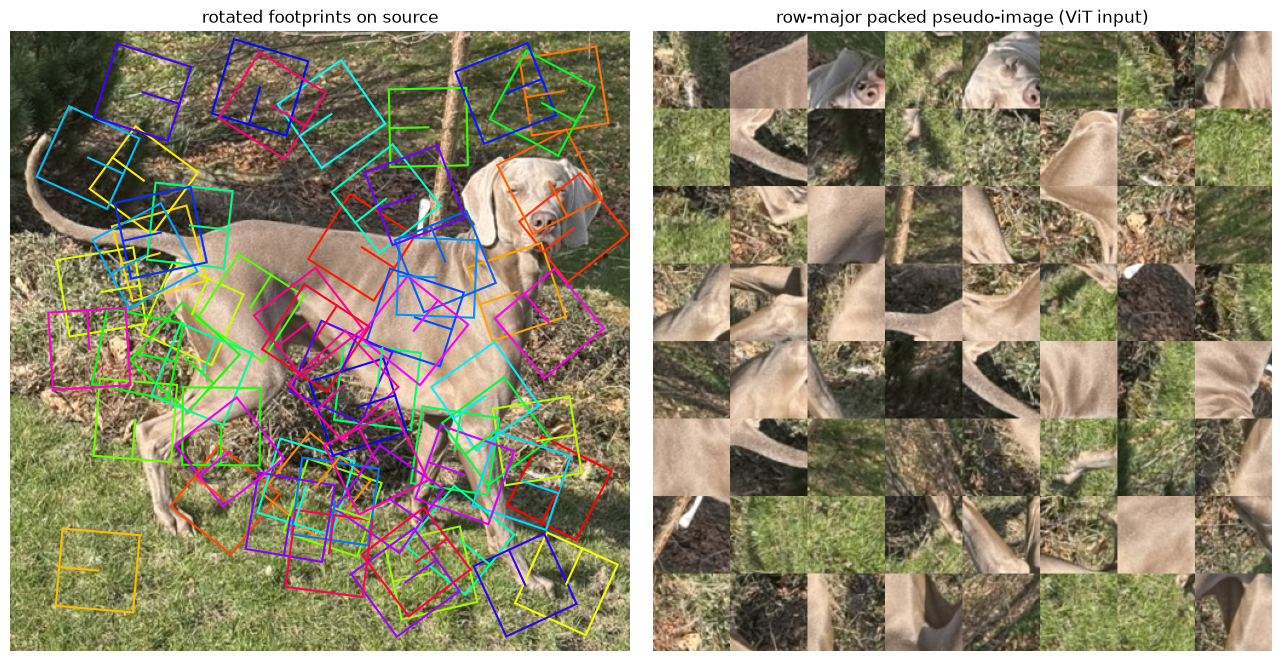

In [6]:
retiled = retile_patches(patches, IMG_SIZE)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(13, 6.5))
draw_rotated_boxes(image, boxes, angles, ax=a0, number=False, title="rotated footprints on source")
from helpers.viz import show_image
show_image(retiled, ax=a1, title="row-major packed pseudo-image (ViT input)")
fig.tight_layout(); plt.show()

## 4. Artefact assessment (the point of this notebook)

### 4a. Empty corners — why we read a diagonal window

If you rotate the bare `patch_size` crop in isolation (`fill_corners=False`), the
corners rotate out of view and fill with black. Reading from a window the size of
the patch **diagonal** and centre-cropping avoids this — at the cost of needing
the edge `margin` above.

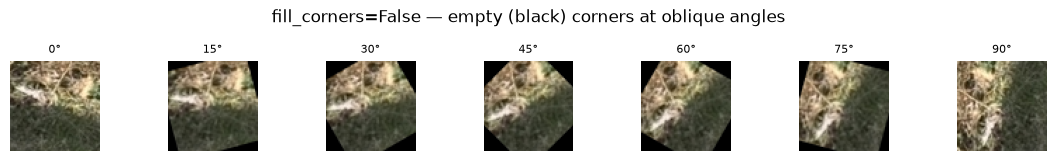

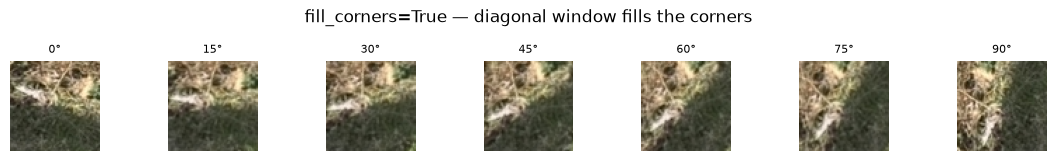

In [7]:
sweep_deg = torch.tensor([0, 15, 30, 45, 60, 75, 90])
sweep = sweep_deg * math.pi / 180
b = boxes[:, 0]

show_rotation_sweep(image, b, sweep, fill_corners=False,
                    title="fill_corners=False — empty (black) corners at oblique angles")
plt.show()
show_rotation_sweep(image, b, sweep, fill_corners=True,
                    title="fill_corners=True — diagonal window fills the corners")
plt.show()

### 4b. Interpolation blur — the confound

This is Validity threat #1. Axis-aligned angles (**0°, 90°, …**) resample almost
exactly onto the pixel grid and stay **sharp**; oblique angles (**≈45°**) require
sub-pixel interpolation and **blur**. A model could read this blur as a proxy for
"how far from axis-aligned" instead of learning genuine relative orientation.

Look along the row below: the 45°/60° patches are visibly softer than 0°/90°.

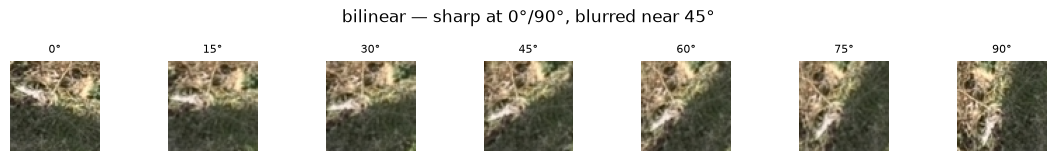

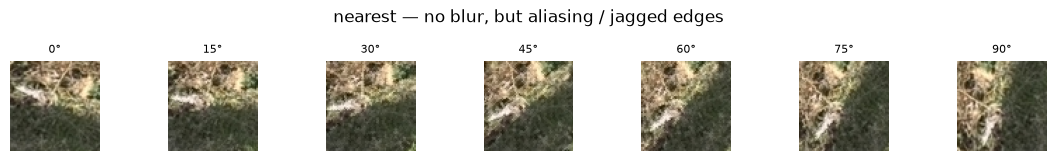

In [8]:
show_rotation_sweep(image, b, sweep, interpolation="bilinear",
                    title="bilinear — sharp at 0°/90°, blurred near 45°")
plt.show()
show_rotation_sweep(image, b, sweep, interpolation="nearest",
                    title="nearest — no blur, but aliasing / jagged edges")
plt.show()

### 4c. Quantifying it

A crude sharpness proxy (mean absolute pixel gradient = high-frequency energy)
across a fine angle sweep, averaged over several patches. The dips at **45° and
135°** are the interpolation blur — a periodic, orientation-correlated signal that
is *exactly* what a confounded model could exploit. (`nearest` is flat-to-rising
by comparison: no blur, just aliasing.)

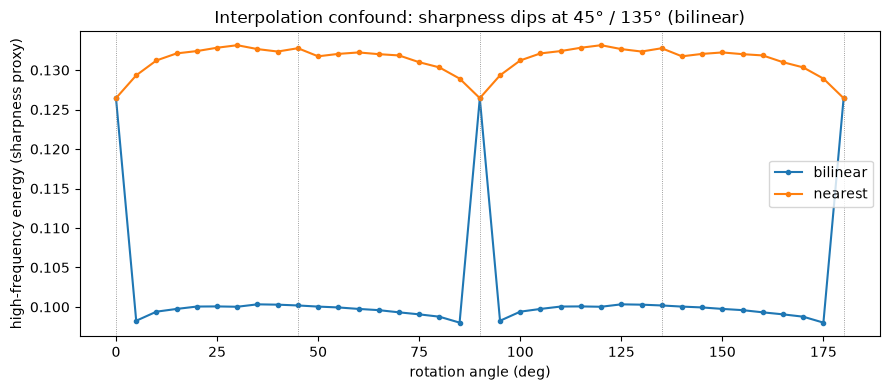

In [9]:
def hf_energy(p):  # mean abs gradient per patch, averaged over the batch
    dx = (p[..., 1:] - p[..., :-1]).abs().mean(dim=(1, 2, 3))
    dy = (p[..., 1:, :] - p[..., :-1, :]).abs().mean(dim=(1, 2, 3))
    return (dx + dy).mean().item()

probe = boxes[:, :16]
deg = torch.arange(0, 181, 5)
rad = deg * math.pi / 180
e_bilinear = [hf_energy(crop_patches_rotated(image, probe, torch.full((probe.shape[1],), float(a)))) for a in rad]
e_nearest = [hf_energy(crop_patches_rotated(image, probe, torch.full((probe.shape[1],), float(a)), interpolation="nearest")) for a in rad]

plt.figure(figsize=(9, 4))
plt.plot(deg, e_bilinear, "-o", ms=3, label="bilinear")
plt.plot(deg, e_nearest, "-o", ms=3, label="nearest")
for d in (0, 45, 90, 135, 180):
    plt.axvline(d, color="grey", lw=0.6, ls=":")
plt.xlabel("rotation angle (deg)"); plt.ylabel("high-frequency energy (sharpness proxy)")
plt.title("Interpolation confound: sharpness dips at 45° / 135° (bilinear)")
plt.legend(); plt.tight_layout(); plt.show()

### 4d. A blur-matching control (flattening the curve)

A natural control (and the one Validity threat #1 calls for): blur the
*sharper*, near-axis-aligned patches down to the sharpness of the most-blurred
angle, so high-frequency energy is **flat** across orientations and the magnitude
cue disappears. We calibrate a per-angle Gaussian σ by bisection to hit the
minimum (≈45°) HF level, then re-plot. The σ needed peaks at 0°/90°/180° (the
sharpest) and is ~0 near 45°/135°.

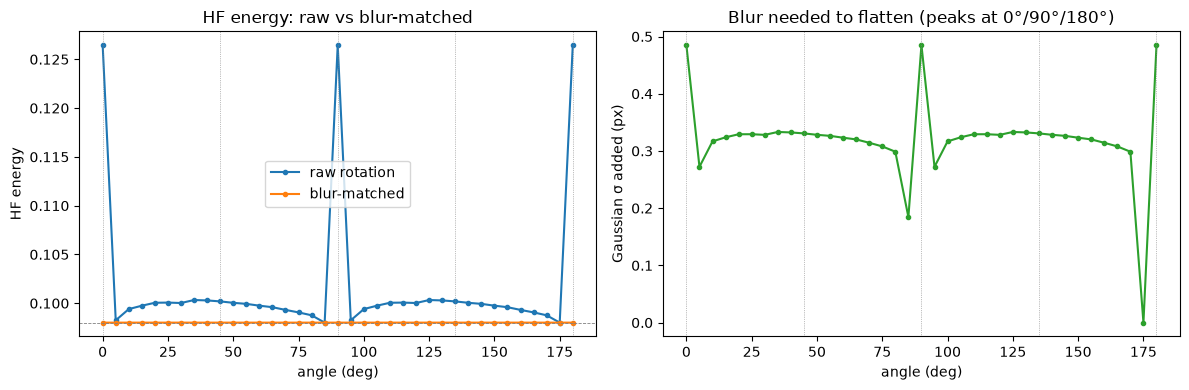

In [10]:
from helpers import gaussian_blur_patches

# reuse the fine angle sweep (rad, deg, probe, hf_energy) from 4c
base = [crop_patches_rotated(image, probe, torch.full((probe.shape[1],), float(a))) for a in rad]
hf_raw = torch.tensor([hf_energy(p) for p in base])
target = hf_raw.min().item()   # match everything down to the most-blurred angle

def match_sigma(p, target, lo=0.0, hi=3.0, iters=20):
    if hf_energy(p) <= target:
        return 0.0
    for _ in range(iters):              # blur is monotone in σ -> bisection
        mid = (lo + hi) / 2
        if hf_energy(gaussian_blur_patches(p, mid)) > target:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

sigmas = torch.tensor([match_sigma(p, target) for p in base])
hf_matched = torch.tensor([hf_energy(gaussian_blur_patches(p, float(s))) for p, s in zip(base, sigmas)])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))
axL.plot(deg, hf_raw, "-o", ms=3, label="raw rotation")
axL.plot(deg, hf_matched, "-o", ms=3, label="blur-matched")
axL.axhline(target, color="grey", lw=0.6, ls="--")
for d in (0, 45, 90, 135, 180):
    axL.axvline(d, color="grey", lw=0.5, ls=":")
axL.set_xlabel("angle (deg)"); axL.set_ylabel("HF energy")
axL.set_title("HF energy: raw vs blur-matched"); axL.legend()
axR.plot(deg, sigmas, "-o", ms=3, color="tab:green")
for d in (0, 45, 90, 135, 180):
    axR.axvline(d, color="grey", lw=0.5, ls=":")
axR.set_xlabel("angle (deg)"); axR.set_ylabel("Gaussian σ added (px)")
axR.set_title("Blur needed to flatten (peaks at 0°/90°/180°)")
fig.tight_layout(); plt.show()

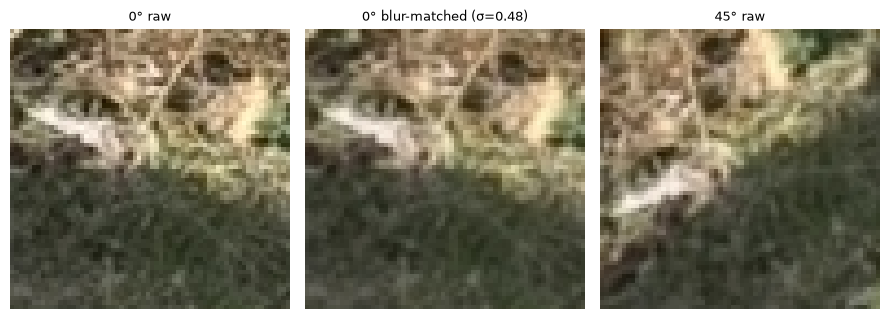

In [11]:
from helpers.viz import _to_hwc

# one patch: 0° raw (sharp) vs 0° blur-matched vs 45° raw — sharpness now comparable
b1 = boxes[:, 0:1]
s0 = match_sigma(crop_patches_rotated(image, probe, torch.zeros(probe.shape[1])), target)
p0 = crop_patches_rotated(image, b1, torch.tensor([0.0]))
p0b = gaussian_blur_patches(p0, float(s0))
p45 = crop_patches_rotated(image, b1, torch.tensor([math.pi / 4]))
fig, ax = plt.subplots(1, 3, figsize=(9, 3.2))
for a, im, t in zip(ax, [p0[0], p0b[0], p45[0]], ["0° raw", f"0° blur-matched (σ={s0:.2f})", "45° raw"]):
    a.imshow(_to_hwc(im)); a.set_axis_off(); a.set_title(t, fontsize=9)
fig.tight_layout(); plt.show()

### 4e. All four controls, side by side

We now compare all four interpolation-confound controls on the same
HF-energy-vs-angle plot, reusing the matched-blur calibration from 4d:

- **(a) matched blur** — per-angle σ flattening to the 45° floor (4d);
- **(b) randomised blur** — σ drawn *independently of* the angle;
- **(c) supersample ×4** — `crop_patches_rotated(..., supersample=4)`: bicubic
  upsample of the source before sampling, so the bilinear read sits on a 4× denser
  grid (near-lossless, angle-independent);
- **(d) dominant isotropic low-pass** — one heavy σ on every patch.

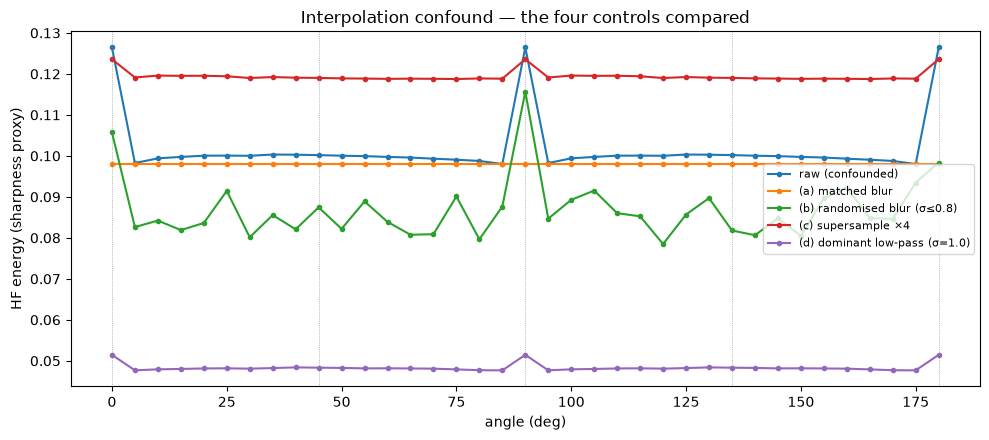

In [12]:
SIGMA_LP = 1.0           # (d) heavy isotropic blur
SIGMA_RAND_MAX = 0.8     # (b) random blur drawn from U[0, SIGMA_RAND_MAX]
gen = torch.Generator().manual_seed(1)

def rot_at(a, **kw):
    return crop_patches_rotated(image, probe, torch.full((probe.shape[1],), float(a)), **kw)

hf_random, hf_super, hf_domlp = [], [], []
for a in rad:
    P = rot_at(a)
    s = torch.rand(probe.shape[1], generator=gen) * SIGMA_RAND_MAX   # (b) σ ⟂ angle
    hf_random.append(hf_energy(gaussian_blur_patches(P, s)))
    hf_super.append(hf_energy(rot_at(a, supersample=4)))             # (c)
    hf_domlp.append(hf_energy(gaussian_blur_patches(P, SIGMA_LP)))   # (d)

plt.figure(figsize=(10, 4.5))
plt.plot(deg, hf_raw, "-o", ms=3, label="raw (confounded)")
plt.plot(deg, hf_matched, "-o", ms=3, label="(a) matched blur")
plt.plot(deg, hf_random, "-o", ms=3, label=f"(b) randomised blur (σ≤{SIGMA_RAND_MAX})")
plt.plot(deg, hf_super, "-o", ms=3, label="(c) supersample ×4")
plt.plot(deg, hf_domlp, "-o", ms=3, label=f"(d) dominant low-pass (σ={SIGMA_LP})")
for d in (0, 45, 90, 135, 180):
    plt.axvline(d, color="grey", lw=0.5, ls=":")
plt.xlabel("angle (deg)"); plt.ylabel("HF energy (sharpness proxy)")
plt.title("Interpolation confound — the four controls compared")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

The same patch at **0°** (sharpest, most confounded) and **45°**
(most blurred) under each control — to see the visual effect *and* the cost
(how much real detail each one sacrifices).

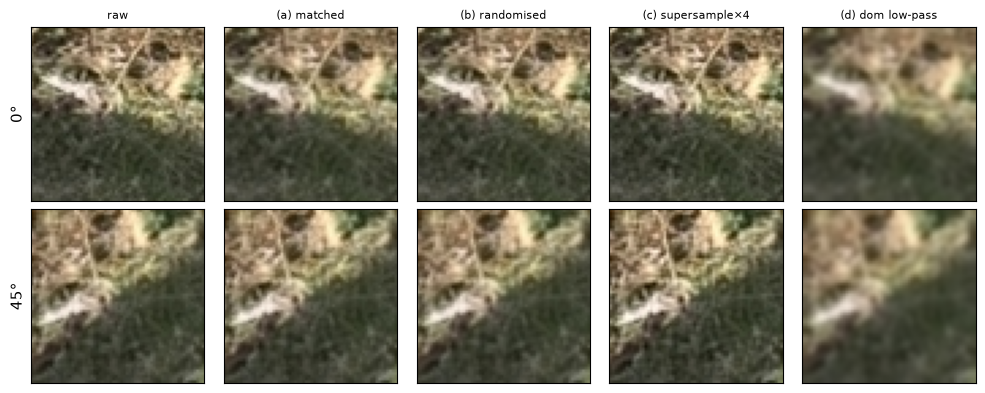

In [13]:
bx = boxes[:, 0:1]

def control_patch(name, phi):
    base = crop_patches_rotated(image, bx, torch.tensor([phi]))
    if name == "raw":
        return base
    if name == "(a) matched":
        s = match_sigma(crop_patches_rotated(image, probe, torch.full((probe.shape[1],), phi)), target)
        return gaussian_blur_patches(base, s)
    if name == "(b) randomised":
        s = float(torch.rand(1, generator=torch.Generator().manual_seed(7)) * SIGMA_RAND_MAX)
        return gaussian_blur_patches(base, s)
    if name == "(c) supersample×4":
        return crop_patches_rotated(image, bx, torch.tensor([phi]), supersample=4)
    if name == "(d) dom low-pass":
        return gaussian_blur_patches(base, SIGMA_LP)

names = ["raw", "(a) matched", "(b) randomised", "(c) supersample×4", "(d) dom low-pass"]
phis = [0.0, math.pi / 4]
phi_lbl = ["0°", "45°"]
fig, axes = plt.subplots(len(phis), len(names), figsize=(2.0 * len(names), 2.0 * len(phis)))
for r, phi in enumerate(phis):
    for cc, name in enumerate(names):
        ax = axes[r, cc]
        ax.imshow(_to_hwc(control_patch(name, phi)[0]))
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0:
            ax.set_title(name, fontsize=8)
        if cc == 0:
            ax.set_ylabel(phi_lbl[r], fontsize=11)
fig.tight_layout(); plt.show()

### Reading the comparison

- **(a) matched blur** flattens to the 45° floor — the magnitude cue is gone, but
  it blurs the well-aligned patches and, being isotropic, leaves the *direction*
  cue (§2).
- **(b) randomised blur** does **not** flatten the mean curve — the systematic dip
  at 45° persists. Random σ only adds angle-independent *variance*, reducing how
  *reliably* blur predicts the angle rather than removing the cue; it approaches a
  real control only as its magnitude grows (toward (d)). (This corrects the
  over-optimistic "uninformative in expectation" framing: the conditional mean is
  still angle-dependent.)
- **(c) supersample ×4** flattens while staying **high** — it preserves real
  high-frequency content (near-lossless) and is the only cheap option that also
  attacks the direction cue, at the source. Best confound/information trade-off.
- **(d) dominant low-pass** flattens but **low** — heaviest signal loss; the
  worst-case stress test.

The §2 caveat stands: HF energy is a *scalar* proxy. (c) fixes the oriented PSF at
the source; (a)/(d) equalise magnitude only; the decisive test is downstream
behaviour under each control (§4 framing).

### Is this *the* control? (research questions)

Flattening HF energy is a genuine first-order control — it removes the *magnitude*
cue (sharpness ↔ distance from axis-aligned). But it opens real questions, several
of which are interesting in their own right:

- **The cost is the experiment.** Matching to the worst angle discards real
  high-frequency content from well-aligned patches, so the pretext task gets
  harder. That is exactly what makes it a control: if `Δφ` *still* learns under
  blur-matching (vs the translation-only baseline), the orientation signal is
  genuine, not the artefact. The raw-vs-matched gap is itself a measurable result.
- **Necessary, not sufficient — anisotropy.** Bilinear-rotation blur is *oriented*:
  its point-spread function points along angle-dependent directions. Isotropic
  Gaussian matching equalises the scalar HF energy we plotted but not the blur
  *direction*, so a model could still read orientation from the anisotropy. A
  stronger control: supersample-then-area-downsample the rotation (near-lossless,
  angle-independent), or a dominant isotropic low-pass.
- **Decorrelate instead of match.** Random per-patch blur (σ drawn independently of
  φ) makes blur *uninformative* about φ in expectation, likely destroying less
  signal than matching everything down to 45°.
- **Circularity.** We flattened the very statistic we measure; passing it does not
  prove no cue remains. The downstream confound controls (blur-matched / randomised
  inputs at evaluation) remain the real test — Validity threat #1.

## 5. The relative orientation target `Δφ`

The RoPART supervision adds, for every ordered pair `(i, j)`, the **relative
orientation** `Δφ = φ_j − φ_i` (reference `i`, target `j` — same convention as the
translation target), encoded as `(cos Δφ, sin Δφ)`:

$$\text{rot}[0, i, j] = \cos(\varphi_j - \varphi_i), \qquad
  \text{rot}[1, i, j] = \sin(\varphi_j - \varphi_i).$$

The `(cos, sin)` encoding is smooth and free of the `±π` wrap, so plain MSE on it
is a valid angular loss; a raw angle is never regressed directly.

In [14]:
rot = relative_orientation(angles)        # (2, N, N): (cos Δφ, sin Δφ)
print("rot table:", tuple(rot.shape), "= (channel, reference i, target j)")
print("\nexample — φ_0 = {:.0f}°, φ_1 = {:.0f}°".format(math.degrees(angles[0]), math.degrees(angles[1])))
dphi01 = math.degrees(((angles[1] - angles[0] + math.pi) % (2 * math.pi) - math.pi))
print(f"  Δφ(0→1)            : {dphi01:+.0f}°")
print(f"  (cos Δφ, sin Δφ)   : ({rot[0,0,1]:+.3f}, {rot[1,0,1]:+.3f})")

rot table: (2, 64, 64) = (channel, reference i, target j)

example — φ_0 = 117°, φ_1 = 32°
  Δφ(0→1)            : -85°
  (cos Δφ, sin Δφ)   : (+0.095, -0.995)


### Structural invariants

The rotational analogue of the translation invariants (and an intrinsic
evaluation axis):

- **diagonal** `(cos, sin) = (1, 0)` — zero relative orientation to itself;
- **`cos` symmetric**: `cos Δφ(i,j) = cos Δφ(j,i)` (cosine is even);
- **`sin` anti-symmetric**: `sin Δφ(i,j) = −sin Δφ(j,i)` — the **rotational
  negative symmetry** (analogue of PART's Figure 6).

In [15]:
check_orientation_invariants(rot)
print("orientation invariants hold: diag (1,0); cos symmetric; sin anti-symmetric ✔\n")
print("Δφ(0→1): (cos, sin) =", [round(v, 3) for v in rot[:, 0, 1].tolist()])
print("Δφ(1→0): (cos, sin) =", [round(v, 3) for v in rot[:, 1, 0].tolist()], " (cos same, sin flipped)")
print("Δφ(5→5): (cos, sin) =", [round(v, 3) for v in rot[:, 5, 5].tolist()], " (diagonal → (1, 0))")

orientation invariants hold: diag (1,0); cos symmetric; sin anti-symmetric ✔

Δφ(0→1): (cos, sin) = [0.095, -0.995]
Δφ(1→0): (cos, sin) = [0.095, 0.995]  (cos same, sin flipped)
Δφ(5→5): (cos, sin) = [1.0, 0.0]  (diagonal → (1, 0))


### See the pairs

`show_orientation_pair` draws the rotated footprints of reference `i` (blue) and
target `j` (red), the two rotated patches with their orientations, and the
resulting `Δφ` / `(cos, sin)` target.

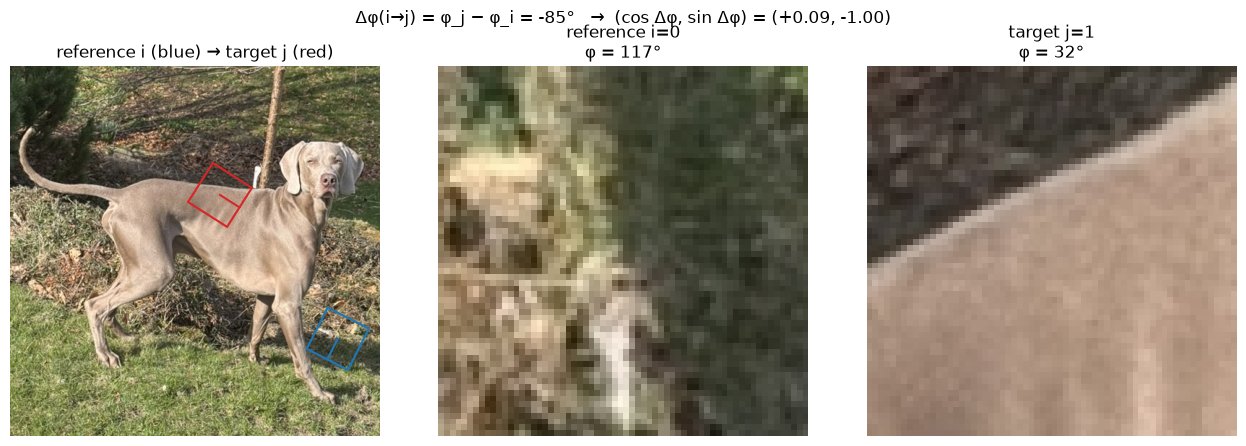

In [16]:
show_orientation_pair(image, boxes, angles, 0, 1)
plt.show()

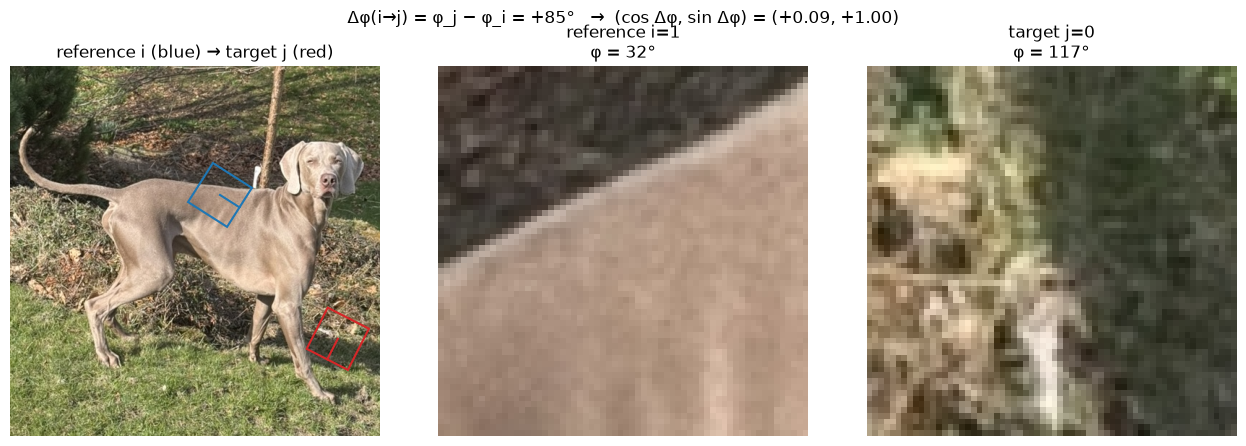

In [17]:
# reverse pair — same patches; cos unchanged, sin flips sign (rotational negative symmetry)
show_orientation_pair(image, boxes, angles, 1, 0)
plt.show()

### The whole tables

`cos Δφ` is symmetric (equal to its transpose); `sin Δφ` is anti-symmetric (equals
minus its transpose), with a zero diagonal — visible directly below.

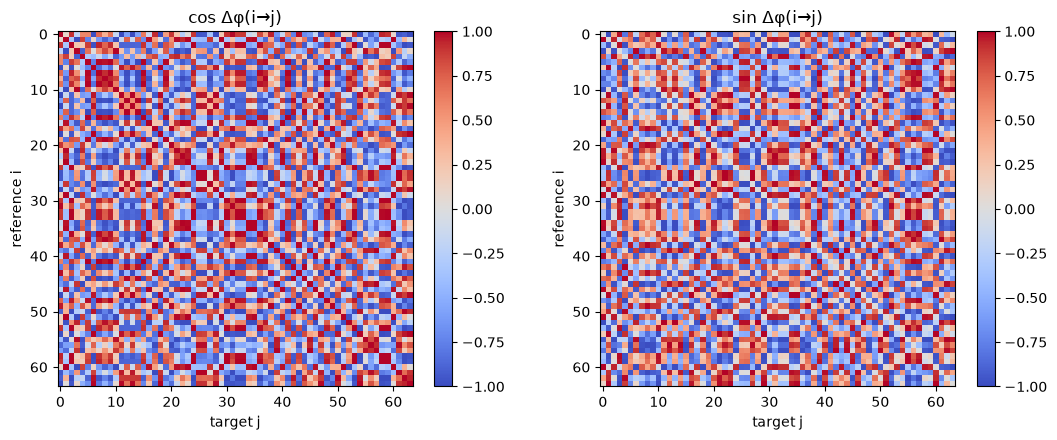

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, c, name in zip(axes, range(2), ("cos Δφ", "sin Δφ")):
    im = ax.imshow(rot[c], cmap="coolwarm", vmin=-1, vmax=1)
    ax.set_title(f"{name}(i→j)")
    ax.set_xlabel("target j"); ax.set_ylabel("reference i")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout(); plt.show()

## Recap

- patches now carry a **uniformly random orientation**, rotated about their
  **centre** with a single resampling; the diagonal-window read avoids empty
  corners;
- the **interpolation confound** is real and orientation-correlated (sharp at
  0°/90°, blurred at 45°/135°) — surfaced here so its control is designed in;
- the RoPART target is `(cos Δφ, sin Δφ)` over ordered pairs, satisfying the
  diagonal, `cos`-symmetric and `sin`-anti-symmetric (rotational negative
  symmetry) invariants.

Next: fold `Δφ` into the per-pair target alongside `(Δx, Δy)` (→ `num_channels`
2 → 4) and wire it through an angle-safe loss in the training path.